## 3.12 양자 게임 이론 (Quantum Game Theory)

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile  # 호환성 수정(qiskit 2.x): assemble 제거됨
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 양자 죄수의 딜레마 게임 회로 정의
def quantum_prisoners_dilemma():
    # 큐비트 2개와 고전 비트 2개로 양자 회로 초기화
    qc = QuantumCircuit(2, 2)

    # 하다마드 게이트로 중첩 생성
    qc.h([0, 1])

    # 제어-NOT(CNOT) 게이트로 큐비트 얽기
    qc.cx(0, 1)

    # 파울리-X 게이트로 플레이어 전략 시뮬레이션
    qc.x(0)  # 플레이어 1 협력
    qc.x(1)  # 플레이어 2 배신

    # 또 다른 CNOT 게이트
    qc.cx(0, 1)

    # 또 다른 하다마드 게이트
    qc.h([0, 1])

    # 큐비트 측정
    qc.measure([0, 1], [0, 1])

    return qc

In [3]:
# 시뮬레이터 초기화
simulator = AerSimulator()

In [4]:
# 양자 회로 생성
qc = quantum_prisoners_dilemma()

In [5]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)

In [6]:
# 회로 조립 (호환성 수정: 구버전 assemble 제거 → 트랜스파일된 회로를 그대로 사용)
qobj = compiled_circuit

In [7]:
# 시뮬레이터에서 회로 실행
result = simulator.run(qobj).result()

In [8]:
# 카운트(측정 결과) 얻기
counts = result.get_counts(qc)

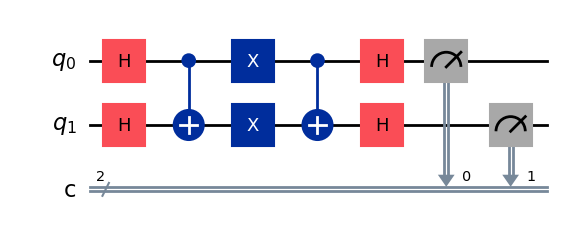

In [9]:
# 트랜스파일 전 회로 그리기
qc.draw('mpl')
plt.show()

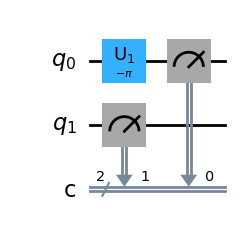

In [10]:
# 트랜스파일 후 회로 그리기
compiled_circuit.draw('mpl')
plt.show()

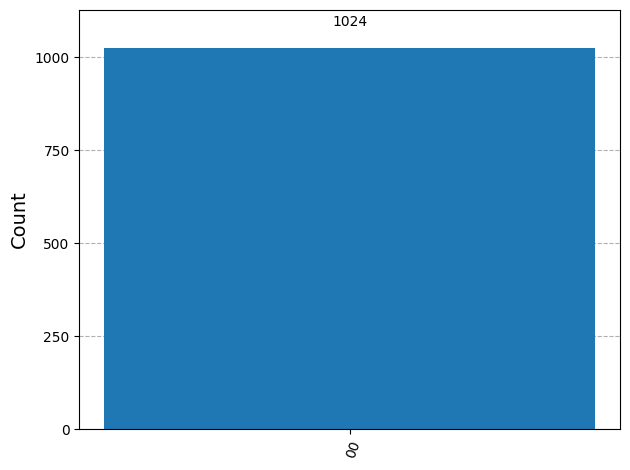

In [11]:
# 결과를 히스토그램으로 그리기
plot_histogram(counts)
plt.show()